In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [23]:
random.randint(140, 195)

169

In [5]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])
#data

In [34]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [51, 69, 43, 64, 67, 70, 54, 60, 66, 64, 47, 54, 48, 52, 57, 49, 60, 70, 64, 69, 57, 52, 64, 68, 44, 49, 51, 43, 47, 55, 66, 66, 54, 47, 57, 55, 43, 47, 59, 46, 45, 65, 57, 53, 60, 52, 42, 68, 65, 70]
여자 키(y축) : [145, 169, 161, 151, 147, 169, 152, 161, 158, 169, 146, 163, 155, 163, 155, 166, 159, 161, 145, 168, 146, 151, 147, 150, 158, 151, 160, 155, 160, 148, 158, 170, 149, 143, 163, 170, 154, 153, 160, 140, 142, 164, 153, 148, 155, 155, 161, 151, 154, 164]
남자 몸무게(x축) : [81, 71, 82, 62, 92, 73, 90, 66, 88, 88, 87, 95, 76, 80, 74, 93, 62, 72, 69, 74, 73, 69, 60, 91, 71, 82, 75, 60, 91, 93, 90, 78, 76, 91, 78, 91, 63, 65, 81, 91, 83, 88, 64, 66, 85, 73, 85, 62, 92, 79]
남자 키(y축) : [195, 173, 175, 170, 192, 193, 160, 163, 173, 162, 180, 182, 194, 175, 189, 163, 175, 183, 163, 187, 178, 186, 183, 185, 169, 192, 181, 169, 174, 161, 170, 174, 166, 160, 186, 170, 181, 186, 169, 169, 171, 193, 184, 172, 166, 194, 190, 191, 164, 174]


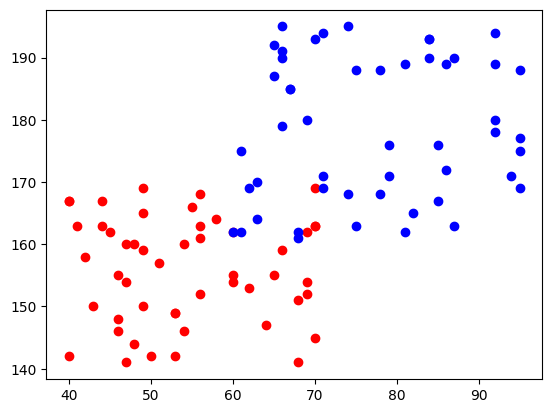

In [6]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [7]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts[0], random_poinsts[1]

([56, 180], [67, 169])

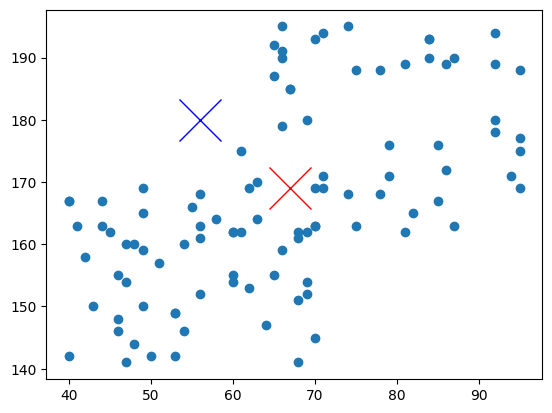

In [8]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b') # 기준점0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r') # 기준점1

In [10]:
# 두점 거리를 return하는 함수 점은 [50,160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [39]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(43, 57)

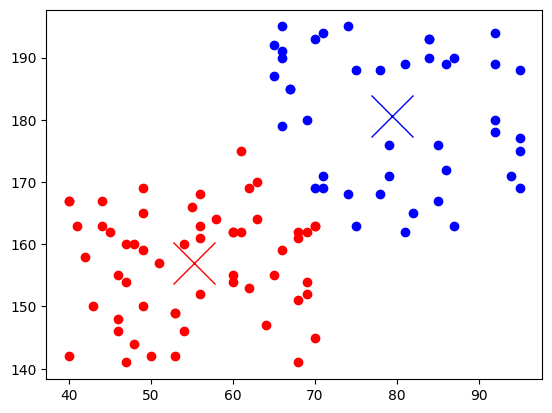

In [40]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

In [41]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_poinsts[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_poinsts[1] = [group1_meanX, group1_meanY]
random_poinsts

[[79.44186046511628, 180.62790697674419],
 [55.280701754385966, 157.01754385964912]]

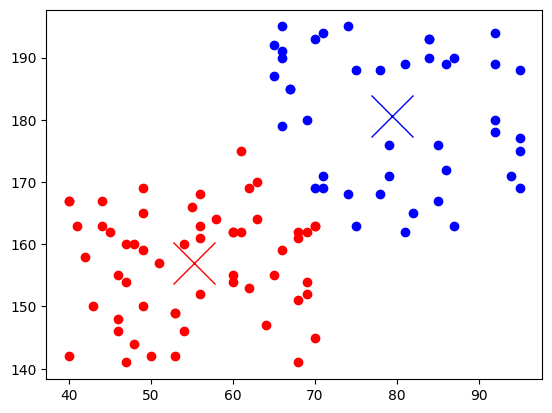

In [42]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

# 3. 군집화 전체 코드(for문 이용)
- 랜덤포인트 2개 지정 - 출력 및 시각화
- for문
    * 랜덤포인트 2지점 기준으로 group0과 group1을 나눔
    * group0의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤 포인트 출력 및 시각화

초기 지점 : [[79, 149], [87, 150]]
1 번째 points : [[59.925, 163.8625], [88.65, 180.4]]
2 번째 points : [[57.10769230769231, 159.01538461538462], [81.57142857142857, 182.31428571428572]]
3 번째 points : [[55.86440677966102, 157.32203389830508], [79.78048780487805, 181.34146341463415]]
4 번째 points : [[55.280701754385966, 157.01754385964912], [79.44186046511628, 180.62790697674419]]
5 번째 points : [[55.280701754385966, 157.01754385964912], [79.44186046511628, 180.62790697674419]]
6 번째 points : [[55.280701754385966, 157.01754385964912], [79.44186046511628, 180.62790697674419]]
7 번째 points : [[55.280701754385966, 157.01754385964912], [79.44186046511628, 180.62790697674419]]
8 번째 points : [[55.280701754385966, 157.01754385964912], [79.44186046511628, 180.62790697674419]]
9 번째 points : [[55.280701754385966, 157.01754385964912], [79.44186046511628, 180.62790697674419]]
10 번째 points : [[55.280701754385966, 157.01754385964912], [79.44186046511628, 180.62790697674419]]


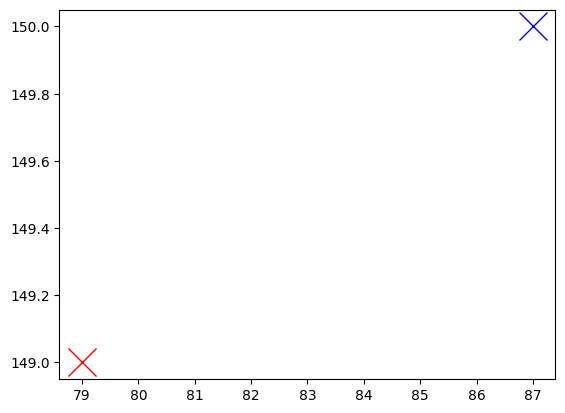

In [48]:
points = [
    [random.randint(40,95), random.randint(140,195)],
    [random.randint(40,95), random.randint(140,195)],
]
print('초기 지점 :', points)
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)
for i in range(1, 11):
    # points 두 지점을 기준으로 group0과 group1 나누기
    group0 = []
    group1 = []
    for info in data:
        if dist(points[0], info) < dist(points[1], info):
            group0.append(info)
        else:
            group1.append(info)
    # group0의 중간점, group1의 중간점으로 points업데이트
    meanX = np.mean([g[0] for g in group0])
    meanY = np.mean([g[1] for g in group0])
    points[0] = [meanX, meanY]
    
    meanX = np.mean([g[0] for g in group1])
    meanY = np.mean([g[1] for g in group1])
    points[1] = [meanX, meanY]
    # 업데이트된 points 출력 및 시각화
    print(i, '번째 points :', points)
    plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=10)
plt.xlim([40,95])